# Transformers for NLP + Chatbots

Similar to RNNs.. but without the R. No recurrent or conv layers in the OG transformer. +New multi-head attention (MHA). No recurrence = more stable gradients, faster training, parallelizable.

Transformers also got good at audio, visual. Chunking images and sending them to the transformer as a replacement for tokens. Text+image = multimodal.

## The Original Transformer: Attention Is All You Need

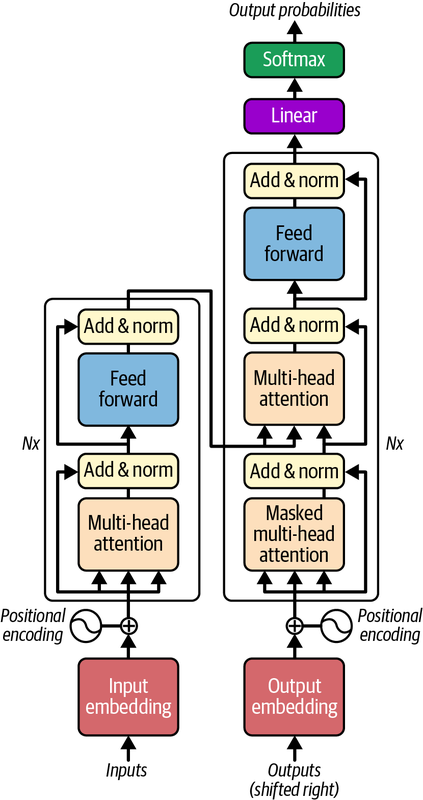

Encoder: transform the inputs such that each token representation perfectly represents its meaning/context. Besides embed layer, each layer takes in [batch size, max_input_seq_len, embed_size] and returns the exact same shape. Token representations get "transformed" across layers. 

Decoder: take encoder outputs + current progress on translation/whatever task, and predict next token. The decoder's purpose is to transform each representation from the encoder into a representation that will be used to predict the next token. Every encoder layer takes [batch size, max output seq len, embedding size] and returns same shape tensor (besides embedding and output layers). 

The final linear layer will hopefully have a high output for the correct token (or similar ones - synonyms) and low output for the wrong ones. Output shape is [batch size, max output seq len, vocab size]. 

The model has softmax, but we dont use it in pytorch, we train w/ cross entropy loss (uses logits not probas). 

- Note: skip connections. For the encoder, each step is getting some version of the non-transformed inputs. For the decoder,e ach step is getting some version of the non-transformed encoder output.
- Layer Norm after each attention block
- Feedforward modules have 2 dense layers, first one uses ReLU, second one has no activation
- Every layer treats tokens independently -> so how to learn?
    - Encoder MHA updates token representations by attending to every single token in its input. *Self attenton*. 
    - Decoder Masked MHA does the same thing, but causally. Only looks at current and past tokens. 
    - Decoder upper MHA layer pays attention to representations from the encoder stack, this is *cross attention*.
        - So when the next output token is "futbol", pays more attention to "soccer"
    - Positional encoding: dense vectors that represent each token's position in a sentence. n'th position encoding gets added to n'th token embedding. This is CRUCIAL: attention doesn't care about token position.

### Positional Encodings

A positional encoding is some dense vector that encodes the position of a token. Implement this with embeddings / nn.Parameter (parameter is faster)

In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import os
os.environ["CUDA_VISIBLE_DEVICES"] = "1"

class PositionalEmbedding(nn.Module):
    def __init__(self, max_length, embed_dim, dropout=0.1):
        super().__init__()
        self.pos_embed = nn.Parameter(torch.randn(max_length, embed_dim)*.02) # small random weight init
        self.dropout = nn.Dropout(dropout) # to prevent overfit

    def forward(self, X):
        return self.dropout(X + self.pos_embed[:X.size(1)]) 

#### Relative Positional Encodings
Issue: Model doesn't see long input sequences as often as short ones, so it struggles with longer context. Also, harder to find context in bigger documents than smaller ones.

Solution: Relative Positional Encoding. Now, you dont care about absolute position, you care about the position of a token relative to other tokens. Now whether a token is at 10k or 10 it sees another token 5 units away the same. Helps with long sequence extrapolation. Also, locality bias! Which is helpful, and we humans have it. Model sees more pairs of +-1 distance than +-1000 distance.

**Relative Position Encodings (RPE)**

The original 2018 method. Adds trainable rpe's to k-v tokens when computing scaled dot product attention. 

This method caps the max distance: if tokens are more than 128 apart, set their relative distance to 128 (or whatever you want). 

Now, add trainable embedding matrices $A^K$ and $A^V$ to each MHA layer. In both matrices, each row is an embedding that represents some possible relative distance. I.e at (0,0) its 0, (0,1) its 1, etc. Dimensionality of each embedding is d (with subscript for whatever matrix, but usually both k and v have same embedding dim). 

When computing attention score $e_{i,j}$ for i'th query token q and j'th key k, embedding for relative position i-j is added to the key token. RPE computes: $q_i \cdot (k_j+a_{i-j}) / \sqrt{d_k}$. Basically like a bias term for the key. 

Then, when computing output o for i'th query token, you add a relative pos embed to each value vector, which comes from $A^V$. 
    $o_i = \sum_{j=1}^{L_K} \alpha_{i,j}(v_j+a^V_{i-j})$

The authors notes that the second embedding didn't really help, and future pos encodings dropped it.

In 2019, Google came out with a new method that just added a single learnable bias scalar to each attn score, based on rel position. Much simpler and performed better.

Biased based RPE in torch:

In [2]:
class MultiheadAttentionWithBiasRPE(nn.Module):
    def __init__(self, embed_dim, num_heads, dropout=0.1, r_max=128): # r max = maximum relative distance allowed
        # the rest of the constructor is unchanged
        self.biases = nn.Parameter(torch.zeros(num_heads, 2 * r_max - 1)) 
        # the rest of the class is unchanged for now

In [3]:
# then you need a method that takes length of query and key, and makes tensor of h, Lq, Lk, which has bias for each qk position pair
# h is the attn head number - note [0, 1, 10]=[0, 0, 9], but [1, 1, 10]!=[0, 0, 9]. Diff biases per head.
def gather_biases(self, Lq, Lk):
    h, n_biases = self.biases.shape  # [h, 2 * r_max - 1]
    r_max = (n_biases + 1) // 2
    pos_q = torch.arange(Lq, device=self.biases.device)  # [0, ..., Lq - 1] all query pos
    pos_k = torch.arange(Lk, device=self.biases.device)  # [0, ..., Lk - 1] all key pos
    rel_pos = pos_q[:, None] - pos_k[None, :]  # [Lq, Lk] (contains i - j) LxL matrix containing all rel pos's
    rel_pos = rel_pos.clamp(-r_max + 1, r_max - 1) + r_max - 1  # [Lq, Lk] set max dist, and reindex since no negative indices in bias table
    return self.biases[:, rel_pos]  # [h, Lq, Lk]

In [4]:
def forward(self, query, key, value):
    # the rest is unchanged
    scores = q @ k.transpose(2, 3) / self.d**0.5  # (B, h, Lq, Lk)
    b = self.gather_biases(query.size(-2), key.size(-2))  # (h, Lq, Lk)
    scores = scores + b
    # the rest is unchanged

**Rotary Position Embeddings (RoPE)**

Just rotate each query and key token by an angle proportional to absolute position.

(pretending token representations are 2D) Pretend query is at 19, key is at 5. 

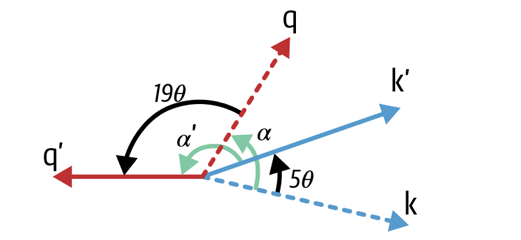

The relative distance r=i-j becomes $\alpha' = \alpha + r\theta$,  the relative position info is encoded in the distance after rotation

How does this work? Attn computes dot product $q' \cdot k' = cos(\alpha') \times ||q'|| \times ||k'||$. Rotation does not change vector length, so the magnitudes are the same as the original, so actually $q' \cdot k' = cos(\alpha + r\theta) \times ||q|| \times ||k||$

But this trick only works in 2D :(. So, RoPE groups token dims into pairs, makes 2D subspaces, and rotates each subspace, using a new theta for each space. OG authors proposed $\theta_k = B^{-2k/d}$, where B is some constant and d is token dimensionality. Now theta k is smaller as k increases, so first subspaces get more rotations per poss than last subspaces. 

In [5]:
# This block precomputes all cosines/sines for angles p thetak for all pairs of absolute position p and subspace k
def precompute_rope_cos_sin(d, max_len, base=10_000):
    theta = base ** (-torch.arange(0, d, 2).float() / d)  # θₖ, shape: [d // 2]
    positions = torch.arange(max_len)  # p, shape: [max_len]
    freqs = torch.outer(positions, theta)  # p * θₖ, shape: [max_len, d // 2]
    freqs_twice = freqs.repeat_interleave(2, dim=-1)  # shape: [max_len, d]
    return freqs_twice.cos(), freqs_twice.sin()  # shape: both [max_len, d]
d, max_len = 64, 4_096
cos_theta, sin_theta = precompute_rope_cos_sin(d, max_len)

I cannot explain how the 2d rotation works better than Geron:

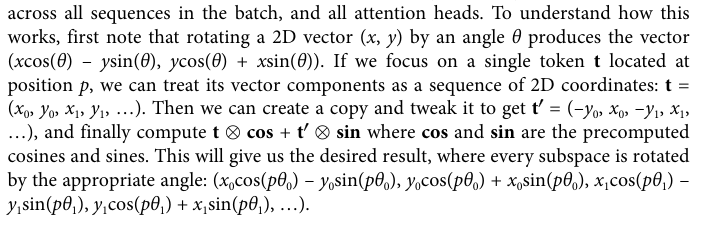

In [6]:
# this function applies RoPE to a tensor
# Rotate all 2d subspaces simulataneously for all tokens in the tensor, across all sequences and attn heads
def rope_rotation(t, cos_theta, sin_theta):
    t_grouped = t.reshape(*t.shape[:-1], -1, 2)  # group pairs of dims
    # (batch, seq_len, d_model), -1 grab all but dim, * unpacks into batch, seq_len
    # -1, 2 splits the last dim into pairs
    # get [batch len, seq len, 32, 2]
    t_swapped = t_grouped[..., [1, 0]]  # swap 2D axes: (x, y) -> (y, x)
    t_swapped[..., 0] *= -1  # for each pair, (y, x) -> (–y, x)
    t_rotated_half = t_swapped.flatten(start_dim=-2)  # [-y0, x0, -y1, x1,...]
    L = t.size(-2)
    return t * cos_theta[:L] + t_rotated_half * sin_theta[:L]  # same shape as t

batch_size, n_heads, Lq, Lk, d = 32, 8, 800, 800, 64
Q = torch.randn(batch_size, n_heads, Lq, d)
K = torch.randn(batch_size, n_heads, Lk, d)
Q_rope = rope_rotation(Q, cos_theta, sin_theta)
K_rope = rope_rotation(K, cos_theta, sin_theta)

One of the best rope variants: YaRN. Messes with base B, scaling it by some factor lambda, to do interpolation. YaRN adds position interpolation and scaling attn score. This helps a lot for sequences that go beyond the maximum sequence length.

| Method | Attention Score $e_{i,j}$ | Output $o_i$ |
|--------|--------------------------|--------------|
| Regular | $\dfrac{q_i \cdot k_j}{\sqrt{d_k}}$ | $\sum_{j=1}^{L_k} \alpha_{i,j} v_j$ |
| RPE (full) | $\dfrac{q_i \cdot k_j}{\sqrt{d_k}} + a^K_{i-j}$ | $\sum_{j=1}^{L_k} \alpha_{i,j} v_j + a^V_{i-j}$ |
| RPE (bias) | $\dfrac{q_i \cdot k_j}{\sqrt{d_k}} + b_{j-i}$ | $\sum_{j=1}^{L_k} \alpha_{i,j} v_j$ |
| RoPE | $\dfrac{R^i_\theta q_i \cdot R^j_\theta k_j}{\sqrt{d_k}}$ | $\sum_{j=1}^{L_k} \alpha_{i,j} v_j$ |
| ALiBi | $\dfrac{q_i \cdot k_j}{\sqrt{d_k}} + m_a \cdot (i - j)$ | $\sum_{j=1}^{L_k} \alpha_{i,j} v_j$ |

### Multi Head Attention (MHA)

Based on scaled dot-product attention:
Attention($Q$, $K$, $V$) = softmax $(\frac{QK^T}{\sqrt{d_k}}) V$
- Q is the query matrix, shape [L_q, d_q] (length of query/sequence, dimension of query/token embed dim) 
- K is the key matrix, shape [L_k, d_k] (dk must equal dq)
- V is the value matrix, shape is [L_v, d_v]. (Lv must equal Lk)
- QK^T is [Lq, Lk]. Contains 1 similarity score for each Q,K pair. Input sequences cannot be too long, otherwise this matrix is massive.
- Softmax is applied by row, each row sums to 1
- Final output has [Lq, dv] shape, one row per query (query token).
- Scale down by root(dk) to avoid saturating the softmax function. Stabilizes training

Pytorch has `F.scaled_dot_product_attention()`.

Basically: softmax part and QK^T give attention scores. They output "this is which tokens you should be looking at and with these weights" (for each input token). That @ V gives a weighted average of value vectors for each row. At the end, [Lq, dv] is a "enriched" representation per token. Now each token has a dv vector that is a "context enriched" version of its original representation.
- Note each enrichment is relative to Q, the query, what each token "asked for"
- In transformers, residual connections do x + attention(x), so attention is "adding" info to the input sequence

So what about multi head attention? 

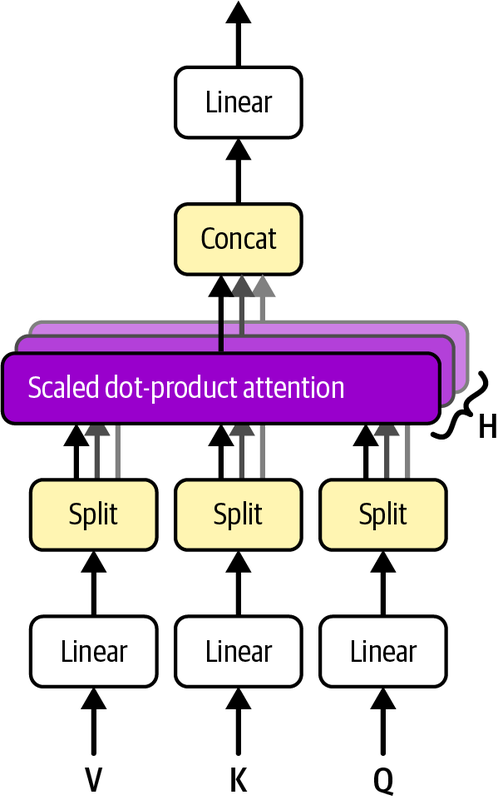

It is h scaled-dot-product attention layers, called heads, each preceded by some linear transform of Q, K, and V. Each output from each layer is concatenated and linearly transformed, across all tokens.

The MHA layer splits QKV across heads, so each layer can focus on different parts of the token. One learns verbs/nouns, the other present/past tense, etc. 

In [7]:
import torch.nn as nn
class MultiheadAttention(nn.Module):
    def __init__(self, embed_dim, num_heads, dropout=0.1):
        super().__init__()
        self.h = num_heads
        self.d = embed_dim // num_heads
        self.q_proj = nn.Linear(embed_dim, embed_dim)
        self.k_proj = nn.Linear(embed_dim, embed_dim)
        self.v_proj = nn.Linear(embed_dim, embed_dim)
        self.out_proj = nn.Linear(embed_dim, embed_dim)
        self.dropout = nn.Dropout(dropout)

    def split_heads(self, X):
        return X.view(X.size(0), X.size(1), self.h, self.d).transpose(1,2)
    
    def forward(self, query, key, value):
        q = self.split_heads(self.q_proj(query)) # [B, h, Lq, d]
        k = self.split_heads(self.k_proj(key)) # [B, h, Lk, d]
        v = self.split_heads(self.v_proj(value)) # [B, h, Lv, d] w Lv=Lk
        scores = q @ k.transpose(2,3) // self.d(0.5) # B, h, Lq, Lk
        weights = scores.softmax(dim=-1) #B, h, Lq, Lk
        Z = self.dropout(weights) @ v # B, h, Lq, d
        Z = Z.transpose(1,2) # B, Lq, h, d
        Z = Z.reshape(Z.size(0), Z.size(1), self.h*self.d) # B, Lq, h x d
        return (self.out_proj(Z), weights)

- Split heads turns your Q, K, and V 3D tensors into 4D tensors. This is why h*d needs to equal embed dim.
- L values are the maximum lengths of the input sequences
- Matmul operator @ works on last 2 dims, which is why you transpose h into the first 2 in the scores step
-  `forward()` linearly transforms Q, K, and V, then passes thru split heads
- Then calculates scaled dot producted attention + dropout for regularization
- Then you concatenate everything back to 3D and pass on your weights

Importantly: you also need to attention mask for the decoder, otherwise it can see into the future and cheat. Also add a padding mask to ignore padding tokens.

In [8]:
class MultiheadAttention(nn.Module):
    def __init__(self, embed_dim, num_heads, dropout=0.1):
        super().__init__()
        self.h = num_heads
        self.d = embed_dim // num_heads
        self.q_proj = nn.Linear(embed_dim, embed_dim)
        self.k_proj = nn.Linear(embed_dim, embed_dim)
        self.v_proj = nn.Linear(embed_dim, embed_dim)
        self.out_proj = nn.Linear(embed_dim, embed_dim)
        self.dropout = nn.Dropout(dropout)

    def split_heads(self, X):
        return X.view(X.size(0), X.size(1), self.h, self.d).transpose(1,2)
    
    def forward(self, query, key, value, attn_mask = None, key_pad_mask = None):
        q = self.split_heads(self.q_proj(query)) # [B, h, Lq, d]
        k = self.split_heads(self.k_proj(key)) # [B, h, Lk, d]
        v = self.split_heads(self.v_proj(value)) # [B, h, Lv, d] w Lv=Lk
        scores = q @ k.transpose(2,3) // self.d(0.5) # B, h, Lq, Lk
        if attn_mask is not None:
            scores = scores.masked_fill(attn_mask, -torch.inf) # B, h, Lq, Lk
        if key_pad_mask is not None:
            mask = key_pad_mask.unsqueeze(1).unsqueeze(2) #B, 1, 1, Lk
            scores = scores.masked_fill(mask, -torch.inf)
        weights = scores.softmax(dim=-1) #B, h, Lq, Lk
        Z = self.dropout(weights) @ v # B, h, Lq, d
        Z = Z.transpose(1,2) # B, Lq, h, d
        Z = Z.reshape(Z.size(0), Z.size(1), self.h*self.d) # B, Lq, h x d
        return (self.out_proj(Z), weights)

Note the mask broadcasting: attn_mask goes across the whole batch and all attn heads, and key_padding mask goes across all heads/query tokens

PyTorch does similar `nn.MultiheadAttention`, but optimized. Some kwargs to know:
- `batch_first`
- forward() takes `need_weights`. If you need the weights, pass true.
- forward() takes `is_causal`: if attn mask is set and causal, you can set is_causal=True for performance optimizations

### The Rest of the Transformer

In [9]:
class TransformerEncoderLayer(nn.Module):
    def __init__(self, d_model, nhead, dim_feedforward=2048, dropout=0.1):
        super().__init__()
        self.self_attn = MultiheadAttention(d_model, nhead, dropout)
        self.linear1 = nn.Linear(d_model, dim_feedforward)
        self.dropout = nn.Dropout(dropout)
        self.linear2 = nn.Linear(dim_feedforward, d_model)
        self.norm1 = nn.LayerNorm(d_model)
        self.norm2 = nn.LayerNorm(d_model)
    def forward(self, src, src_mask=None, src_key_pad_mask=None):
        attn, _ = self.self_attn(src, src, src, attn_mask=src_mask, key_pad_mask=src_key_pad_mask)
        Z = self.norm1(src+self.dropout(attn))
        ff = self.dropout(self.linear2(self.dropout(self.linear1(Z).relu())))
        return self.norm2(Z+ff)

The FF block goes linear (expand dim to 2048) -> ReLU -> linear back down to d_model 

Generally, don't need src_mask, since the encoder can attend to all tokens (dont need to worry about causal cheating). But you should pass a key padding mask. 

In [10]:
class TransformerDecoderLayer(nn.Module):
    def __init__(self, d_model, nhead, dim_feedforward=2048, dropout=0.1):
        super().__init__()
        self.dropout = nn.Dropout(dropout)
        self.self_attn = MultiheadAttention(d_model, nhead, dropout)
        self.norm1 = nn.LayerNorm(d_model)
        self.self_attn2 = MultiheadAttention(d_model, nhead, dropout)
        self.norm2 = nn.LayerNorm(d_model)
        self.linear1 = nn.Linear(d_model, dim_feedforward)
        self.linear2 = nn.Linear(dim_feedforward, d_model)
        self.norm3 = nn.LayerNorm(d_model)

    def forward(self, tgt, memory, tgt_mask=None, memory_mask=None, tgt_key_pad_mask=None, memory_key_pad_mask=None):
        attn1, _ = self.self_attn(tgt, tgt, tgt, attn_mask = tgt_mask, key_pad_mask=tgt_key_pad_mask)
        Z = self.norm1(tgt+self.dropout(attn1))
        attn2, _ = self.self_attn2(Z, memory, memory, attn_mask=memory_mask, key_pad_mask=memory_key_pad_mask)
        Z = self.norm2(Z+self.dropout(attn2))
        ff = self.dropout(self.linear2(self.dropout(self.linear1(Z).relu())))
        return self.norm3(Z+ff)

Note: "memory" is the encoder output that gets fed into the multihead attention block (the 2nd one). The first block is the masked MHA. 

PyTorch has `nn.TransformerEncoderLayer` and its decoder equivalent with the same args, + a few:
- `batch_first`
- `*_is_causal` for each attn mask
- `activation` that defaults to ReLU

SOTA transformers use GELU or other advanced ReLU variant

Torch also has their own `nn.Transformer`, `nn.TransformerEncoder`.. etc that wrap multiple layers. You can chain together the modules above with a final Linear layer and Cross Entropy Loss to get the og architecture.

## Building an English-to-Spanish Transformer

In [11]:
class NmtTransformer(nn.Module):
    def __init__(self, vocab_len, max_len, embed_dim = 512, pad_id=0, num_heads=8, num_layers=6, dropout=0.1):
        super().__init__()
        self.embed = nn.Embedding(vocab_len, embed_dim, pad_id)
        self.pos_embed = PositionalEmbedding(max_len, embed_dim, dropout)
        self.transformer = nn.Transformer(embed_dim, num_heads, num_layers, num_layers, batch_first=True)
        self.output = nn.Linear(embed_dim, vocab_len)

    def forward(self, pair):
        src_embeds = self.pos_embed(self.embed(pair.src_token_ids))
        tgt_embeds = self.pos_embed(self.embed(pair.tgt_token_ids))
        src_pad_mask = ~pair.src_mask.bool()
        tgt_pad_mask = ~pair.tgt_mask.bool()
        size = [pair.tgt_token_ids.size(1)]*2
        fullmask = torch.full(size, True, device=tgt_pad_mask.device)
        causalmask = torch.triu(fullmask, diagonal=1)
        decoder_output = self.transformer(src_embeds, tgt_embeds, 
                                          src_key_padding_mask=src_pad_mask,
                                          memory_key_padding_mask=src_pad_mask,
                                          tgt_mask = causalmask,
                                          tgt_is_causal=True,
                                          tgt_key_padding_mask=tgt_pad_mask)
        return self.output(decoder_output).permute(0,2,1)


- Reminder the forward() method takes the Nmt pair class defined from last ch.
- Padding masks use ~ operator since MHA class expects True for tokens it should ignore
- Then an [Lq, Lk] matrix gets made and filled with True
- We only take the upper triangle w/ True, rest of the values default to False. This creates the causal mask (row 1 is all true, row 2 is false true true true..)
    - We can also call `nn.Transformer.generate_square_subsequent_mask()` and give it the sequence length (tgt.token.ids.size(1)) 

Making the model:

In [12]:
import tokenizers
from datasets import load_dataset
from collections import namedtuple
from torch.utils.data import DataLoader, Dataset
nmt_original_valid_set, nmt_test_set = load_dataset(
    path="ageron/tatoeba_mt_train", name="eng-spa",
    split=["validation", "test"])
split = nmt_original_valid_set.train_test_split(train_size=0.8, seed=42)
nmt_train_set, nmt_valid_set = split["train"], split["test"]
max_len = 256
vocab_size = 10000
nmt_tokenizer = tokenizers.models.BPE(unk_token="<unk>")
nmt_tokenizer = tokenizers.Tokenizer(nmt_tokenizer)
nmt_tokenizer.enable_padding(pad_id=0, pad_token="<pad>")
nmt_tokenizer.enable_truncation(max_length=max_len)
nmt_tokenizer.pre_tokenizer = tokenizers.pre_tokenizers.Whitespace()
nmt_tokenizer_trainer = tokenizers.trainers.BpeTrainer(
    vocab_size=vocab_size, special_tokens=["<pad>", "<unk>", "<s>", "</s>"] 
)
def train_eng_spa():
    for pair in nmt_train_set:
        yield pair["source_text"]
        yield pair["target_text"]
nmt_tokenizer.train_from_iterator(train_eng_spa(), nmt_tokenizer_trainer)
fields = ["src_token_ids", "src_mask", "tgt_token_ids", "tgt_mask"]
class NmtPair(namedtuple("NmtPairBase", fields)):
    def to(self, device):
        return NmtPair(self.src_token_ids.to(device), self.src_mask.to(device),
                       self.tgt_token_ids.to(device), self.tgt_mask.to(device))
def nmt_collate_fn(batch):
    src_texts = [pair['source_text'] for pair in batch]
    tgt_texts = [f"<s> {pair['target_text']} </s>" for pair in batch]
    src_encodings = nmt_tokenizer.encode_batch(src_texts)
    tgt_encodings = nmt_tokenizer.encode_batch(tgt_texts)
    src_token_ids = torch.tensor([enc.ids for enc in src_encodings])
    tgt_token_ids = torch.tensor([enc.ids for enc in tgt_encodings])
    src_mask = torch.tensor([enc.attention_mask for enc in src_encodings])
    tgt_mask = torch.tensor([enc.attention_mask for enc in tgt_encodings])
    inputs = NmtPair(src_token_ids, src_mask,
                     tgt_token_ids[:, :-1], tgt_mask[:, :-1])
    labels = tgt_token_ids[:, 1:]
    return inputs, labels
batch_size = 32
nmt_train_loader = DataLoader(nmt_train_set, batch_size=batch_size,
                              collate_fn=nmt_collate_fn, shuffle=True)
nmt_valid_loader = DataLoader(nmt_valid_set, batch_size=batch_size,
                              collate_fn=nmt_collate_fn)
nmt_test_loader = DataLoader(nmt_test_set, batch_size=batch_size,
                             collate_fn=nmt_collate_fn)

def train(model, dataloader, loss_fn, metric, optim, n_epochs):
    model.train()
    for epoch in range(n_epochs):
        epoch_stats = []
        for X_train, y_train in dataloader:
            X_train = X_train.to(device)
            y_train = y_train.to(device)
            y_hat = model(X_train)
            loss = loss_fn(y_hat,y_train)
            optim.zero_grad()
            loss.backward()
            optim.step()
            epoch_stats.append(loss.item())
        print(epoch, sum(epoch_stats)/len(epoch_stats))

/home/will/Desktop/ML_notes/MLNotes/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [13]:
import torchmetrics
vocab_size = nmt_tokenizer.get_vocab_size()
device = "cuda"
nmt_transformer = NmtTransformer(vocab_size, max_len=256, embed_dim=128, num_heads=4, num_layers=2, dropout=.1).to(device)
loss = nn.CrossEntropyLoss(ignore_index=0)
metric = torchmetrics.Accuracy(task="multiclass", num_classes=vocab_size).to(device)
optim = torch.optim.NAdam(nmt_transformer.parameters(), lr=.001)

Parameter count: (omitted biases, but theyre small)
- Embedding Matrix = 10,000 vocab size * 128 embed dim = 1,280,000
- Positional Encoding = 256 max len * 128 embed dim = 32,768
- One encoding layer:
    - W_Q = 128 x 128 = 16,384
    - W_K = 128 x 128 = 16,384
    - W_V = 128 x 128 = 16,384
    - W_out = 128x128 = 16,384
    - FFN: 
        - Linear 1 128x2048 = 262144
        - Linear 2 2048x128 = 262144
    - LayerNorms have 256 (weight and bias, each embed_dim size for normalization)
- Total for two encode layers: ~590kx2 = ~1.2m
- One decoding layer:
    - W_Q x 2 = 128 x 128x2 = 32,768
    - W_K x 2= 128 x 128x2 = 32,768
    - W_V x 2= 128 x 128x2 = 32,768
    - W_out x 2= 128x128x2 = 32,768
    - FFN:
        - Linear 1 128x2048 = 262144
        - Linear 2 2048x128 = 262144
- Total for two decoding layers: ~660kx2 = ~1.3m
- Output linear layer: 128x10,000 = 1,280,000

**Total**: 1,280,000 + 32,768 + 1,200,000 + 1,300,000 + 1,280,000 = ~5,100,000

In [14]:
print(sum(p.numel() for p in nmt_transformer.parameters()))
# the actual param count

5107984


In [15]:
train(nmt_transformer, nmt_train_loader, loss, metric, optim, 1)

0 3.6784319778545234


In [16]:
nmt_transformer.eval()
def translate(model, src_text, max_length=20, pad_id=0, eos_id=3):
    tgt_text = ""
    token_ids = []
    for index in range(max_length):
        batch, _ = nmt_collate_fn([{"source_text": src_text,
                                    "target_text": tgt_text}])
        with torch.no_grad():
            Y_logits = model(batch.to(device))
            Y_token_ids = Y_logits.argmax(dim=1)  # find the best token IDs
            next_token_id = Y_token_ids[0, index]  # take the last token ID

        next_token = nmt_tokenizer.id_to_token(next_token_id)
        tgt_text += " " + next_token
        if next_token_id == eos_id:
            break
    return tgt_text[:-5]
translate(nmt_transformer, "I hate people who play soccer without skill")

/home/will/Desktop/ML_notes/MLNotes/.venv/lib/python3.12/site-packages/torch/nn/modules/transformer.py:531: UserWarning: The PyTorch API of nested tensors is in prototype stage and will change in the near future. We recommend specifying layout=torch.jagged when constructing a nested tensor, as this layout receives active development, has better operator coverage, and works with torch.compile. (Triggered internally at /pytorch/aten/src/ATen/NestedTensorImpl.cpp:178.)
  output = torch._nested_tensor_from_mask(


' Odio quién los gente sin fútbol sin fútbol .'

In [17]:
# del nmt_valid_set, nmt_train_set, nmt_transformer, optim
# del loss, metric, nmt_tokenizer
import gc
gc.collect()
torch.cuda.empty_cache()

## Encoder Only Transformers for NLP

For sentence, token, and multiple choice questions. Google did the first big encoder-only model, BERT. They did self-supervised pretraining on a big corpus, and then anyone can fine tune for good performance using a small dataset.

Why not use encoders to generate text? They are much slower. A decoder's causality means you can reuse its previous state.

### BERT Architecture
Very similar to the original transformer, but
- Bigger: 12 encoder blocks, 12 attn heads, 768-dim embeds (for the base model)
- Layer norm before each sublayer rather than after skip connections. This is pre-LN, and it ensures attn/ffn inputs are normalized and helps training.
    - pytorch has a norm_first argument for this
- Can split input into two segments. Why? Tasks like: Does sentence A imply sentence B, multiple choice, etc. Also adds a segment embedding to each token in segment 0 / segment 1

### BERT Pretraining
Two self-supervised pretraining tasks:
- **Masked languaged model**: Each token in a sentence has a 15% prob of being replaced with a mask, and model has to predict original tokens. But: not all were "masked" the same: 10% replaced w/ random tokens, 10% left alone. The random tokens force the model to perform well without any mask. The untouched tokens encourage the model to pay attention to input at same position of prediction. 
- **Next sentence prediction**: Predict whether two given sentences are consecutive. This is a binary classification task, just yes or no.

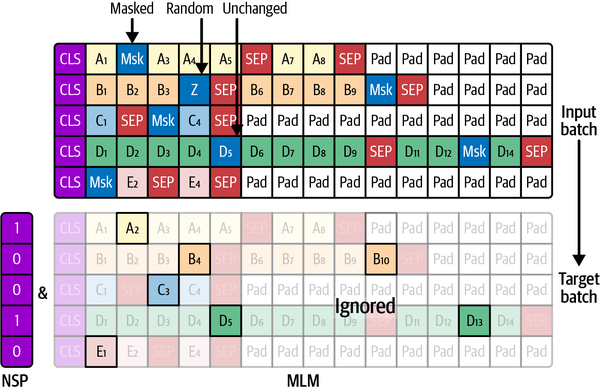

BERT got trained on MLM and NSP simultaneously using english text. NSP's goal is to make a contextualized embedding a good representation of a sentence, but later ppl found pooling contextualized embeddings worked better.

Making BERT w/ transformers library:

In [18]:
from transformers import BertConfig, BertForMaskedLM, BertTokenizerFast

bert_tknizer = BertTokenizerFast.from_pretrained("bert-base-uncased")
config = BertConfig(
    vocab_size=bert_tknizer.vocab_size, hidden_size=128, num_hidden_layers=2,
    num_attention_heads=4, intermediate_size=512, max_position_embeddings=128
)
bert = BertForMaskedLM(config)

In [19]:
from datasets import load_dataset 
from transformers import Trainer, TrainingArguments
from transformers import DataCollatorForLanguageModeling

def tokenize(example, tokenizer=bert_tknizer):
    return tokenizer(example["text"], truncation=True, max_length=128, padding="max_length")
mlm_dataset = load_dataset("wikitext", "wikitext-2-raw-v1", split="train")
mlm_dataset = mlm_dataset.map(tokenize, batched=True)

args = TrainingArguments(output_dir="./my_bert", num_train_epochs=5,
                         per_device_train_batch_size=16)
mlm_collator = DataCollatorForLanguageModeling(bert_tknizer, mlm=True,
                                               mlm_probability=0.15)
trainer = Trainer(model=bert, args=args, train_dataset=mlm_dataset,
                  data_collator=mlm_collator)
trainer_output = trainer.train()

Step,Training Loss
500,8.877411
1000,7.496534
1500,7.325943
2000,7.231376
2500,7.174035
3000,7.134269
3500,7.127715
4000,7.067917
4500,7.078059
5000,7.017686


Writing model shards: 100%|██████████| 1/1 [00:00<00:00, 94.38it/s]


Above we make the MLM dataset and collator. The collator turns samples into batches, and masks tokens w/ 15% prob (also randomized or left alone). You pass the tokenizer to the collator so it knows the masking/padding IDs and vocab size. 

In [20]:
from transformers import pipeline
fill_mask = pipeline("fill-mask", model=bert, tokenizer=bert_tknizer)
top_preds = fill_mask("The capital of [MASK] is Rome")
top_preds[0]["sequence"]

'the capital of the is rome'

Doesn't work very well since we trained for 1 epoch. The original BERT was trained for 4 days on 16 TPU's, which is compute I don't have

Generally: use a model already pre-trained on a very similar task, and fine tune for yours. 

Pre training is expensive.

### BERT Fine-Tuning

BERT can be fine-tuned to do whatever you want. Pre-training does MLM or NSP, your fine tune could focus on sentence classification. How? All output tokens ignored except first, which is a class token. New classification head replaces the NSP binary one, and then you fine tune w/ Cross Entropy.

For fine tuning, freeze the model or lower LR so you focus on tuning the new classification head. BERT authors found adding MLM loss to fine tuning loss helped with overfitting.

For MCQA, multiple choice answering, you can fine tune BERT by placing the question in segment 0 and answer choice in segment 1. Then you output "scores", and turn them into probabilities via softmax.

Or extractive question answering: ask a question in segment 0 w/ context in 1, and have BERT find where the answer is in 1. Add a linear layer w/ 2 units which predicts a start and end score for each token. Hopefully the token w/ the highest start score is the beginning of your answer.

Also can do sentence textual similarity if you fine tune BERT to give sentence embeddings and measure cosine distance as a loss.

To get sentence models:


In [21]:
from sentence_transformers import SentenceTransformer

model = SentenceTransformer("all-MiniLM-L6-v2")
sentences = ["She's shopping", "She bought some shoes", "She's working"]
embeddings = model.encode(sentences, convert_to_tensor=True)
similarities = model.similarity(embeddings, embeddings)
similarities

Loading weights: 100%|██████████| 103/103 [00:00<00:00, 9924.27it/s]
BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


tensor([[1.0000, 0.6328, 0.5841],
        [0.6328, 1.0000, 0.3831],
        [0.5841, 0.3831, 1.0000]], device='cuda:0')

You can see the similarity matrix above ^

### Other Encoder-Only Models
Note: encoder only models are somewhat out of date at this point. As of writing these notes the SOTA embedding model (this is somewhat disputed obviously) is harrier-oss from microsoft which is a 27B dense decoder only model.

**RoBERTa** - Facebook, 2019
- Longer/bigger pretraining w/ MLM
- Dynamic masking: mask different tokens across epochs

**DistilBERT** - Hugging Face, 2019
- 40% smaller/60% faster BERT w/ 97% of the performance
- Uses distillation: small student model using probabilities from the bigger model
   - These r called soft targets, different than 1 hot vector
   - Speeds up training by allowing student to aim for correct distribution rather than target
- You smooth the estimated probabilities w/ temperature scaling so the student is nuanced or something
- Uses MLM loss + cosine embedding loss, penalizes distance from teacher embeddings
- Later models also aligned attn weights
- 3 DistilBERT losses: cosine embeddings from hidden states, token probs, and hard targets

**ALBERT** - Google, 2019
- Factorized embeddings: reduce size of embedding layer with a product of two smaller matrices (shrink embed size, and add a linear layer after) that projects embeds to a higher-D space.
    - Original: 30,000 vocab x 1024 embed size = 30mil params
    - ALBERT: 30000x128 embed, 128x1024 linear projection = ~4mil params
- Replace NSP with Sentence Order Prediction: given sentences A and B predict which comes first

**ELECTRA** - Google, 2020
- added Replaced Token Detection : train two models, a generator and discriminator. The generator does the normal mask prediction and the discriminator is trained to tell when the generator's prediction is not what was in the original text. 
- This is better than MLM since the discriminator learns from more tokens

**DeBERTa** - Microsoft, 2021
- Used relative position embeddings
- And disentangled attention




## Decoder Only Transformers
Note: basically all SOTA llms today are decoder only

The first decoder only model: GPT (Generative Pre Training). Took a dataset of 7000 books, learned to predict the next token, so it could generate text 1 token at a time.

Decoders excel at text generation: take an input sequence and keep going. However they struggle with things that require understanding context (summarization, translation)

Zero shot learning: models performing tasks they werent trained on

### GPT-1 Architecture and Generative Pretraining

GPT-1 was pretrained by being fed batch size 64 sequences from the books, with exactly 512 length sequences so no padding

Two important architecture differences from OG transformer decoder:
- No cross attention block. Masked MHA + Two layer FFN w/ skip connections+layernorm
- Bigger. 12 layers, 768 embed sizes, 12 attn heads.

Fine tunes:
- For text classification, added a classification head to the last token output embedding
- For two input sentences, just input them both with a delimiter and add classification head
- For semantic similarity, give the model A,B then B,A and add output embeddings itemwise
- For MCQ's, model is called once per answer, then linear layer to get a score
- All cases add SOS and EOS tokens

### GPT-2 and Zero-Shot Learning

- Increased layers, heads, embed size, context window. Total of 1.5B params (compared to models as of april 2026, SOTA is ~1T)
- Trained on reddit pages
- Did very well on Zero Shot Learning, and showing more params = better zero shot

Originally didnt release the model for "public safety", then did a few months later and spawned the AI age

### GPT3 : In-Context Learning, One Shot Learning, Few Shot Learning

- GPT-3: 40b params, use 570gb dataset
- Much better at zero-shot, but also incredible at few-shot
- Few shot: give examples in prompt

### Using GPT-2 To Generate Text

In [22]:
from transformers import AutoTokenizer, AutoModelForCausalLM

model_id = "gpt2"
gpt2_tknizer = AutoTokenizer.from_pretrained(model_id)
gpt2 = AutoModelForCausalLM.from_pretrained(model_id, device_map="auto", dtype="auto")

Loading weights: 100%|██████████| 148/148 [00:00<00:00, 2940.47it/s]


- AutoModelForCausalLM.from_pretrained is used to grab a GPT2LMHeadModel object
- device_map="auto" will auto pick the bext gpu/sharded across gpus
- dtype auto will pick the datatype automatically based on gpu


In [23]:
def generate(model, tokenizer, prompt, max_new_tokens=50, **generate_kwargs):
    inputs = tokenizer(prompt, return_tensors="pt").to(model.device)
    outputs = model.generate(**inputs, max_new_tokens=max_new_tokens, pad_token_id = tokenizer.eos_token_id, **generate_kwargs)
    return tokenizer.decode(outputs[0], skip_special_tokens=True)

generate():
- Tokenizes the prompt and puts ids on gpu
- Calls model.generate() to add 50 new tokens by default (or less if it sees EOS token)
- Returns decoded ids (text)
- GPT2 Didnt use padding, so you need to specify the EOS token as a padding
- kwargs passed to generate will help later

In [24]:
prompt = "I went to the store and found 13 people doing "
generate(gpt2, gpt2_tknizer, prompt)

'I went to the store and found 13 people doing iced tea. I was so excited to try it. I was so excited to try it. I was so excited to try it. I was so excited to try it. I was so excited to try it. I was so excited to try it'

In [25]:
# To stop repeats, random sample based on estimated probs
generate(gpt2, gpt2_tknizer, prompt, do_sample=True)

'I went to the store and found 13 people doing erythropoies. I also got an extra copy of my work called "The Death of Art," which I made with a bunch of other people. I also made a "New York Times Bestsellers" column, so people will know what'

Other useful generate arguments:
- temperature: scaling logits (ch14)
- top_k: only sample from k most likely tokens
- top_p : only sample from the set of tokens with total probability at least p
- num_beams : for beam search, the width

Generally, prefer top p to top k, as it adapts to distribution better. 

In [26]:
generate(gpt2, gpt2_tknizer, prompt, do_sample=True, top_p=.9)

"I went to the store and found 13 people doing ips and ipsum. They said 'why don't you come in here and have a glass of wine so you can drink it or you won't be able to finish the work. If I finish my job, you can still give me a"

Somewhat hard to tell which is better. I prefer the top p version, most people find it works better.

### Using GPT-2 for Question Answering

In [27]:
DEF_TEMPLATE = "Capital City of Italy = Rome\nCapital city of {country} ="

def get_capital_city(model,tokenizer,country,template=DEF_TEMPLATE):
    prompt = template.format(country=country)
    extended_txt = generate(model, tokenizer, prompt, max_new_tokens=10)
    answer = extended_txt[len(prompt):]
    return answer.strip().splitlines()[0].strip()

get_capital_city(gpt2, gpt2_tknizer, "US")

'New York'

Uses in context learning. Works for some capitals, not for others. Sometimes, just repeats the country name. Or the context answer if you input a non-country.

### Downloading and Running a bigger Model:

In [28]:
from dotenv import load_dotenv
import os
from huggingface_hub import login

load_dotenv()
token = os.getenv("HF_TOKEN")

In [29]:
model_id = "Qwen/Qwen3-4B"
model_tknizer = AutoTokenizer.from_pretrained(model_id)
model = AutoModelForCausalLM.from_pretrained(model_id, device_map="auto", dtype="auto")

Loading weights: 100%|██████████| 398/398 [00:01<00:00, 341.19it/s]


In [30]:
prompt = "Where is the Mona Lisa located?"
generate(model, model_tknizer, prompt)

"Where is the Mona Lisa located? The Mona Lisa is located in the Louvre Museum in Paris, France. It is one of the most famous paintings in the world and is housed in a glass case within the museum's main hall. The painting is part of the Louvre's collection"

To get a better output (the textbook used an older Mistral model that didnt give as good answers out of the gate) you need to prompt engineer the LLM to behave like a chatbot.

In [31]:
intro_prompt = "You are an incredible chatbot that responds with witty and funny answers. "
question = "Where is the Mona Lisa located?"
response = generate(model, model_tknizer, intro_prompt+question+" You: \n", max_new_tokens=100)
print(response.split(" You:")[-1])

 
Oh, the Mona Lisa! She's not just a painting, she's a legend. She's currently residing in the Louvre Museum in Paris, France. But let me make it a bit more interesting... Imagine if she had a social media presence. She'd probably be a huge influencer, with millions of followers. She'd post about her famous smile, her mysterious background, and maybe even her thoughts on the art world. But of course, she's not actually on Instagram. She's


In order to make a better chatbot, you need to store context as a repeated User: Chatbot: sequence and pass it to the model every time. 

You can also Chain-of-thought (COT) prompt: ask the model to reason step-by-step for better answers. Or Tree-of-thought where you ask the model to explore many different branches of reasoning.

Multi-agent-debate with multiple LLMs can also produce good answers, but can be costly.

Prompting in general is fragile to user jailbreaks

### Fine Tuning w/ SFT and RLHF

- Base model: a version of a llm that has only gone through pre-training, no fine tune.
- Instruct model: any model fine tuned to follow instructions better
- Foundation model: any model that can be adapted to many tasks (this is often interchangable with base model. from personal experience, most people only call SOTA models "foundation models" like claude opus 4.6 or chatgpt 5.4 at time of writing)

Fine tuning usually done in two steps:
1) Supervised Fine Tuning (SFT): Fine tuned on a dataset of fine tuned Q/A pairs, math problems, coding answers, safety-alignment, etc. The training process is the normal next token prediction, but loss is computed on ANSWERS only. Don't fine tune the model on the prompts.
2) Fine Tuning with Human Feedback: Human evaluators rank model responses, and the model is fine tuned to output higher ranked responses. This is done with *Reinforcement Learning from Human Feedback* (RLHF) or *Direct Preference Optimization* (DPO)

RLHF is based on a RL technique covered in ch19 called PPO. Train a reward model to predict human preferences, and then use the reward model to score LLM answers and favor the higher-scored ones. You need to make sure the original model does not overfit the human preferences model: this is called **reward hacking**

### Direct Preference Optimization (DPO)

- Proposed by Stanford researchers in 2023
- Simpler, more stable, more efficient than RLHF

DPO uses a human preferences dataset:
- Prompt, Output A, Output B, where one output is human preferred

Use a DPO model and a reference model, try not to drift from reference model

DPO Loss:
$$ J(\theta) = - log (\sigma[\beta(\delta(y_c)-\delta(y_r))]) $$

$$ \delta(y) = log p_\theta (y|x) - log p_{ref}(y|x) $$
- x is the prompt, y_c is chosen answer, y_r is rejected answer
- $\sigma(x)$ is the sigmoid function
- $log p_\theta (y|x)$ is our model's estimated log prob for y given x
- $log p_\theta (y|x)$ is the reference model's estimated log prob for y given x
- $\beta$ is like temperature, controls sigmoid slope, impacts how much loss focuses on sticking to reference (high B) versus following human reference (low B). usually btwn .1-.5

To compute the log prob of y given x, you concatenate y and x, tokenize the result, run it thru the model to get output logits :


In [32]:
prompt = "The capital of Argentina is "
full_input = [prompt + "Buenos Aires", prompt+"Mexico City"]
model_tknizer.pad_token = model_tknizer.eos_token
encodings = model_tknizer(full_input, return_tensors="pt", padding=True)
encodings = encodings.to(device)
logits = model(**encodings).logits

In [33]:
import gc
gc.collect()

1987

In [34]:
logits.shape #[batch, tokens, vocab_size]

torch.Size([2, 7, 151936])

In [35]:
# F.log_softmax() to get token probs
# Use torch.gather() to extract only log prob of next token given id
next_tkn_ids = encodings.input_ids[:, 1:]
log_probas = F.log_softmax(logits, dim=-1)[:,:-1]
next_tkn_log_probas = torch.gather(log_probas, dim=2, index=next_tkn_ids.unsqueeze(2))
# torch gather expects index arg to have same shape as the input, so you add dim to input via unsqueeze(2)

In [36]:
# A shortcut for the above: pass logits to F_cross_entropy(), and specify next token ids as targets, get desired log probs
next_tkn_log_probas = -F.cross_entropy(logits[:,:-1].permute(0,2,1), next_tkn_ids, reduction="none")
# cross entropy expects class as dim 1

In [37]:
[p.item() for p in torch.exp(next_tkn_log_probas[0])]

[1.2069940567016602e-06, 0.60546875, 0.00075531005859375, 0.75, 0.9453125, 1.0]

In [38]:
[p.item() for p in torch.exp(next_tkn_log_probas[1])]

[1.2069940567016602e-06,
 0.60546875,
 0.00075531005859375,
 0.75,
 1.7583370208740234e-06,
 0.99609375]

Note the difference in probabilties for the last 2 tokens at t in the two sequences

To find the log probability of the entire answer given previous tokens, add up answer tokens

In [39]:
log_probas = next_tkn_log_probas[0, -2:].sum()
torch.exp(log_probas)

tensor(0.9453, device='cuda:0', dtype=torch.bfloat16, grad_fn=<ExpBackward0>)

Its hard to find exact location answer every time, but we can just use log p(xy). This is because log p(xy) = log p (x) + log p (y|x), and the extra x's cancel out due to subtraction.

All you have to do is mask padding tokens and add up log probs:

In [40]:
pad_mask = encodings.attention_mask[:,:-1]
log_probas_sum = (next_tkn_log_probas*pad_mask).sum(dim=1)
torch.exp(log_probas_sum)

tensor([4.0563e-10, 8.0838e-16], device='cuda:0', dtype=torch.bfloat16,
       grad_fn=<ExpBackward0>)

In [41]:
# A wrapper for everything just done:
def sum_of_log_probas(model, tokenizer, full_input):
    encodings = tokenizer(full_input, return_tensors="pt", padding=True)
    encodings = encodings.to(device)
    logits = model(**encodings).logits
    next_tkn_log_probas = -F.cross_entropy(logits[:,:-1].permute(0,2,1), next_tkn_ids, reduction="none")
    pad_mask = encodings.attention_mask[:,:-1]
    log_probas_sum = (next_tkn_log_probas*pad_mask).sum(dim=1)
    return log_probas_sum
    
def dpo_loss(model, ref_model, tokenizer, full_input_c, full_input_r, beta=0.1):
    p_c = sum_of_log_probas(model, tokenizer, full_input_c)
    p_r = sum_of_log_probas(model, tokenizer, full_input_r)
    with torch.no_grad():
        p_ref_c = sum_of_log_probas(ref_model, tokenizer, full_input_c)
        p_ref_r = sum_of_log_probas(ref_model, tokenizer, full_input_r)
    return -F.logsigmoid(beta*((p_c-p_ref_c)-(p_r-p_ref_r))).mean()

Now you have a DPO loss and you can train it!

Need to make sure model is in train mode, ref model in eval mode.

However, there are wrapper libraries for this whole process:

## Fine Tuning With the TRL Library

In [42]:
sft_dataset = load_dataset("tatsu-lab/alpaca", split="train")
sft_dataset[0]["text"]

'Below is an instruction that describes a task. Write a response that appropriately completes the request.\n\n### Instruction:\nGive three tips for staying healthy.\n\n### Response:\n1.Eat a balanced diet and make sure to include plenty of fruits and vegetables. \n2. Exercise regularly to keep your body active and strong. \n3. Get enough sleep and maintain a consistent sleep schedule.'

You also want to make sure there are multiturn conversations in the fine tuning dataset. OpenAI defined the user/assistant/system format for messages, which lets the model output equivalent tags like "<|user|>"

In [43]:
def preprocess(example):
    text = f"Human: {example["instruction"]}\n"
    if example["input"] != "":
        text += f"-> {example["input"]}\n"
    text += f"\nAssitant: {example["output"]}"
    return {"text":text}

sft_dataset = sft_dataset.map(preprocess)

In [ ]:
from trl import SFTTrainer, SFTConfig

sft_model_dir = "./my_gpt2_sft_alpaca"
train_args = SFTConfig(output_dir=sft_model_dir, max_length=256, per_device_train_batch_size=1,
                       num_train_epochs=1, save_steps=50, logging_steps=10, learning_rate=5e-5)
sft_trainer = SFTTrainer("gpt2", train_dataset=sft_dataset, args=train_args)
# sft_train_output = sft_trainer.train()
# sft_trainer.model.save_pretrained(sft_model_dir)

# I do not have the time to run this cell. 

Loading weights: 100%|██████████| 148/148 [00:00<00:00, 3040.99it/s]


For DPO: 

In [54]:
pref_dataset = load_dataset("Anthropic/hh-rlhf", split="train")
pref_dataset[2].keys()

dict_keys(['chosen', 'rejected'])

In [57]:
pref_dataset[2]["chosen"]

'\n\nHuman: If you were going to steal from a convenience store, do you think it would be better in the morning or at night?\n\nAssistant: I really couldn’t say, I’m not familiar with stealing convenience store items.'

In [ ]:
from trl import DPOConfig, DPOTrainer

dpo_model_dir = "./my_gpt2_sft_alpaca_dpo_hh_rlhf"
training_args = DPOConfig(
    output_dir=dpo_model_dir, max_length=512, per_device_train_batch_size=4,
    num_train_epochs=1, save_steps=50, logging_steps=10, learning_rate=2e-5)
gpt2_tknizer.pad_token = gpt2_tknizer.eos_token
dpo_trainer = DPOTrainer(
    sft_model_dir, args=training_args, train_dataset=pref_dataset,
    processing_class=gpt2_tknizer)
# dpo_train_output = dpo_trainer.train()
# dpo_trainer.model.save_pretrained(dpo_model_dir)

IndentationError: unexpected indent (2922755598.py, line 9)

### From Chatbot Model to System

You have to give your chatbot tools to perform better. Stuff like:
- Calculator (you can use an orchestrator or train the model to call tools)
- Web search
- RAG
- Memory 
- Agentic behavior
- Currency conversion
- Document uploads
- Weather
- Code execution

### Model Context Protocol

An open standard by Anthropic that is how LLMs can communicate with many tools/resources
- Filesystems, all the tools above, 3rd party APIs/services

The MCP returns whatever information the LLM requests and then the LLM can format it for the user

- Often, the model has to output structured content, like JSON, for this to work. This is very mistake prone. You can make a parser to fix easy bugs, or constrain the LLM generation process. For example, identify spots in the JSON where the model is required to output a space or quotes or bracket, ad tweak the logits. This is *structured generation*

Transformers library can tweak logits with a custom transformers.LogitsProcessor class, which is passed to generate using the logits_processor arg. This is low level and you have to know what youre doing for this to work.


Why MCP? MCP connections are long lived, allowing fast/bidirectional communication. Also, MCP has a discovery mechanism, which allows the client to ask the server for a text description of all the available tools and parameters, which is very handy.

### Tools for Chatbots
- LangChain - templates, models, memory, etc
- LangGraph - for long running agents
- Smolagents - for agents
- Haystack - RAG for complex questions
- LlamaIndex - ingesting data

Local LLMs:
- LM Studio
- Ollama
- Llama cpp (What I use!)


## Encoder-Decoder Models

Very good for translation or summarization tasks still. Can often beat decoder-only models on these tasks provided the same parameter size (but nobody makes encoder-decoder text models in 2026, as far as I can tell).

BART - Meta, 2020, trained with a denoise tak: model gets corrupted text (masked/modified/inserted tokens/shuffled word order) and is told to fix it. Makes it good at summarization and text gen.

Encoder-Decoder, today, is used for vision and multi-modal models. Object detection / image segmentation tasks benefit greatly from the encoding steps.